In [1]:
from maze_nca.config import EnvConfig
from maze_nca.nca import NCAModel
from maze_nca.task_generation import (
    make_single_wall_env,
    add_goal_distance_channel,
    add_problem_distance_channel
)
from maze_nca.utils import plot_channel, benchmark_reward

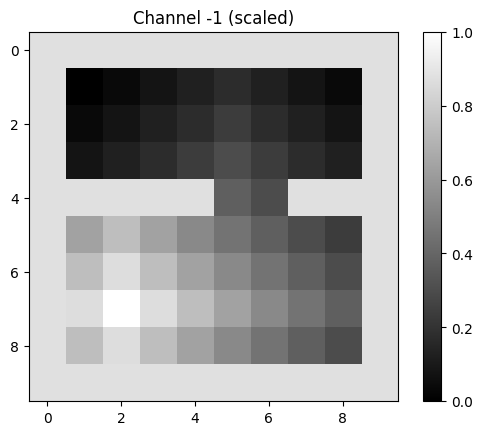

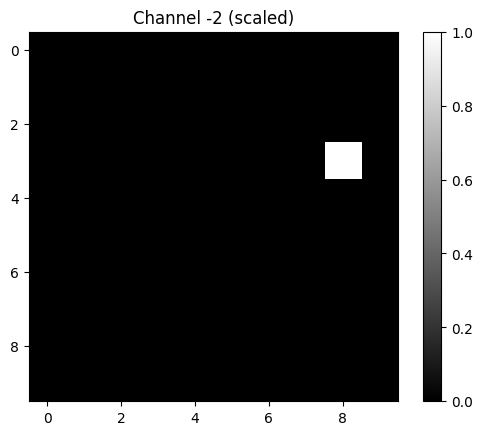

In [2]:
# Visualize Channels
config = EnvConfig()
ca = NCAModel(
    living_channels=8,
    num_neurons=64,
    death_threshold=0.05
)
env = make_single_wall_env(
    height=10, width=10,
    hole_size=2, seed=87293910
)
env = add_goal_distance_channel(env, config)
env = add_problem_distance_channel(env, config)
env = ca.egg(env, config)
plot_channel(env, -1)
plot_channel(env, -2)

In [3]:
config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled = False
)
ca = NCAModel(
    living_channels=8,
    num_neurons=64,
    death_threshold=0.05
)

benchmark_reward(
    config,
    ca,
    batch_size = 10,
    height = 10,
    width = 10,
    living_channels = 8
)


    Starting Reward: 4.497728406308084e-17
    Goal Reward: 0.387595534324646
    Space-Filled Reward: 0.007992858067154884
    Half-Space-Filled Reward: 0.007992858067154884
    Self-Destruct Reward: 0.0
    
